In [1]:
import warnings
warnings.filterwarnings("ignore")
import os
os.environ["NIXTLA_ID_AS_COL"] = "true"
import numpy as np
np.set_printoptions(suppress=True)
np.random.seed(1)
import random
random.seed(1)
import pandas as pd
pd.set_option("max_colwidth", 100)
pd.set_option("display.precision", 3)
from utilsforecast.plotting import plot_series as plot_series_utils
import seaborn as sns
sns.set_style("whitegrid")
import matplotlib.pyplot as plt
plt.style.use("ggplot")
plt.rcParams.update({
    "figure.figsize": (8, 5),
    "figure.dpi": 100,
    "savefig.dpi": 300,
    "figure.constrained_layout.use": True,
    "axes.titlesize": 12,
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "legend.title_fontsize": 10,
    "grid.alpha": 1.0,
})
import matplotlib as mpl
from cycler import cycler
mpl.rcParams['axes.prop_cycle'] = cycler(color=["#000000", "#000000"])
from fpppy.utils import plot_series

mpl.colormaps.register(
    mpl.colors.ListedColormap(
        ["#000000", "#2f2fff"], name="black_and_blue"),
    force=True,
)
mpl.colormaps.register(
    mpl.colors.ListedColormap(
        ["#000000", "#D55E00"], name="black_and_orange"),
    force=True,
)
mpl.colormaps.register(
    mpl.colors.ListedColormap(
        ["#000000", "#000000"], name="black"),
    force=True,
)
mpl.colormaps.register(
    mpl.colors.ListedColormap(
        ["#000000", "#569CC6", "#D55F03"],
        name='black_and_2color',
    ),
    force=True
)
mpl.colormaps.register(
    mpl.colors.ListedColormap(
        ["#000000", "#D55F03", "#569CC6", "#13A076"],
        name='black_and_3color',
    ),
    force=True
)
mpl.colormaps.register(
    mpl.colors.ListedColormap(
        ["#000000", "#D55F03", "#569CC6", "#13A076", "#CC79A7"],
        name='black_and_4color',
    ),
    force=True
)
mpl.colormaps.register(
    mpl.colors.ListedColormap(
        ["#D55F03", "#569CC6", "#13A076", "#CC79A7"],
        name='r_colors',
    ),
    force=True
)

In [2]:
from functools import partial
from statsmodels.tsa.seasonal import STL
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.stats.diagnostic import acorr_ljungbox
from utilsforecast.evaluation import evaluate
from utilsforecast.feature_engineering import pipeline, trend
from utilsforecast.losses import rmse, mae, mape as _mape, mase, quantile_loss, mqloss
from statsforecast import StatsForecast
from statsforecast.models import (
    HistoricAverage,
    Naive,
    RandomWalkWithDrift,
    SeasonalNaive,
    SklearnModel,
)
from fpppy.models import LinearRegression

def mape(df, models, id_col = "unique_id", target_col = "y"):
    df_mape = _mape(df, models, id_col=id_col, target_col=target_col)
    df_mape.loc[:, df_mape.select_dtypes(include="number").columns] *= 100
    return df_mape

In [3]:
gdp_df = (
    pd.read_csv("global_economy.csv", parse_dates=["ds"])
    [["unique_id", "ds", "GDP", "Population"]]
    .assign(
        GDP=lambda x: x["GDP"].interpolate(),
        Population=lambda x: x["Population"].interpolate(),
        y=lambda x: x["GDP"] / x["Population"],
    )
)

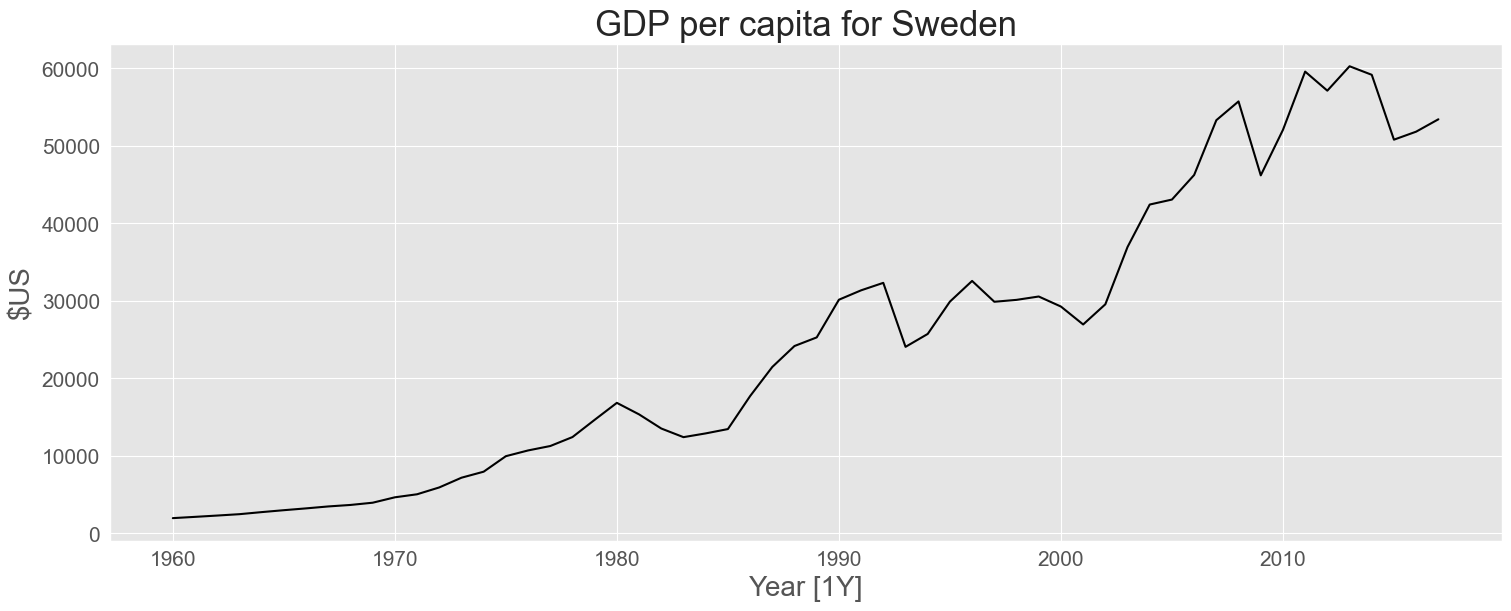

In [4]:
plot_series(gdp_df, ids=["Sweden"],
    xlabel="Year [1Y]", ylabel="$US", title="GDP per capita for Sweden")

In [5]:
sweden_df = (
    gdp_df
    .loc[lambda x: x["unique_id"] == "Sweden"]
    [["unique_id", "ds", "y"]]
)

In [6]:
train_features, valid_features = pipeline(
    sweden_df, features=[trend], freq="Y", h=3)

trend_model = SklearnModel(LinearRegression())
sf = StatsForecast(models=[trend_model], freq="Y")

In [7]:
sf.fit(df=train_features)
fcasts = sf.predict(h=3, X_df=valid_features)

# We are using a LinearRegression wrapper that provides
# the following method for calculating prediction intervals
model = sf.fitted_[0][0].model_["model"]
fcasts = model.add_prediction_intervals(
    fcasts, valid_features.rename(columns={"trend": "x1"}))

fcasts

,unique_id,ds,LinearRegression,LinearRegression-lo-95,LinearRegression-hi-95,LinearRegression-lo-80,LinearRegression-hi-80
0,Sweden,2017-12-31,56165.506,46066.615,66264.397,49570.311,62760.700
1,Sweden,2018-12-31,57225.849,47109.566,67342.132,50619.297,63832.401
2,Sweden,2019-12-31,58286.193,48151.970,68420.416,51667.925,64904.461


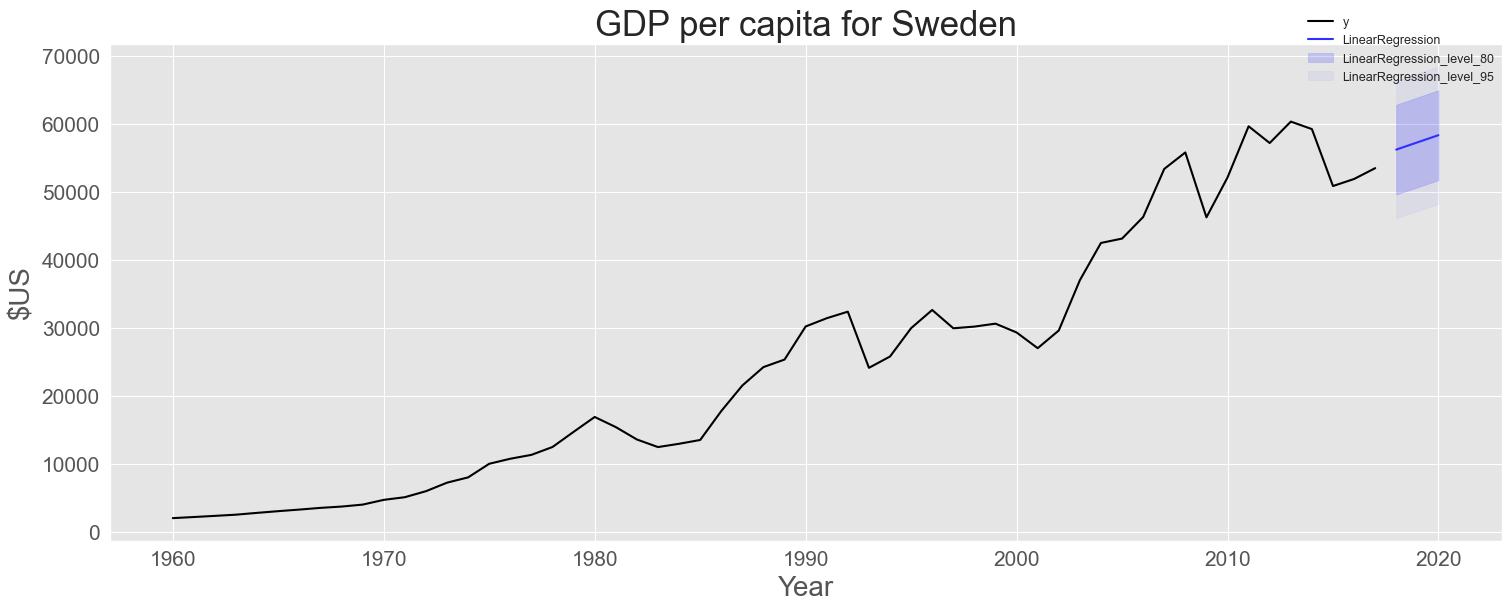

In [9]:
plot_series(sweden_df, fcasts, ids=["Sweden"], level=[80, 95],
    xlabel="Year", ylabel="$US", title="GDP per capita for Sweden",
    palette="black_and_blue", rm_legend=False)

In [10]:
production_df = pd.read_csv("aus_production_formatted.csv",
    parse_dates=["ds"])
bricks_df = (
    production_df.loc[lambda x: (
        (x["unique_id"] == "Bricks")
        & (x["ds"].between("1970", "2004-12"))
    )]
    .dropna()
)

In [11]:
avg_method = HistoricAverage()
sf = StatsForecast(models=[avg_method], freq="Q")

In [12]:
naive_method = Naive()
sf = StatsForecast(models=[naive_method], freq="Q")

In [13]:
seasonal_naive_method = SeasonalNaive(4)
sf = StatsForecast(models=[seasonal_naive_method], freq="Q")

In [14]:
drift_method = RandomWalkWithDrift()
sf = StatsForecast(models=[drift_method], freq="Q")

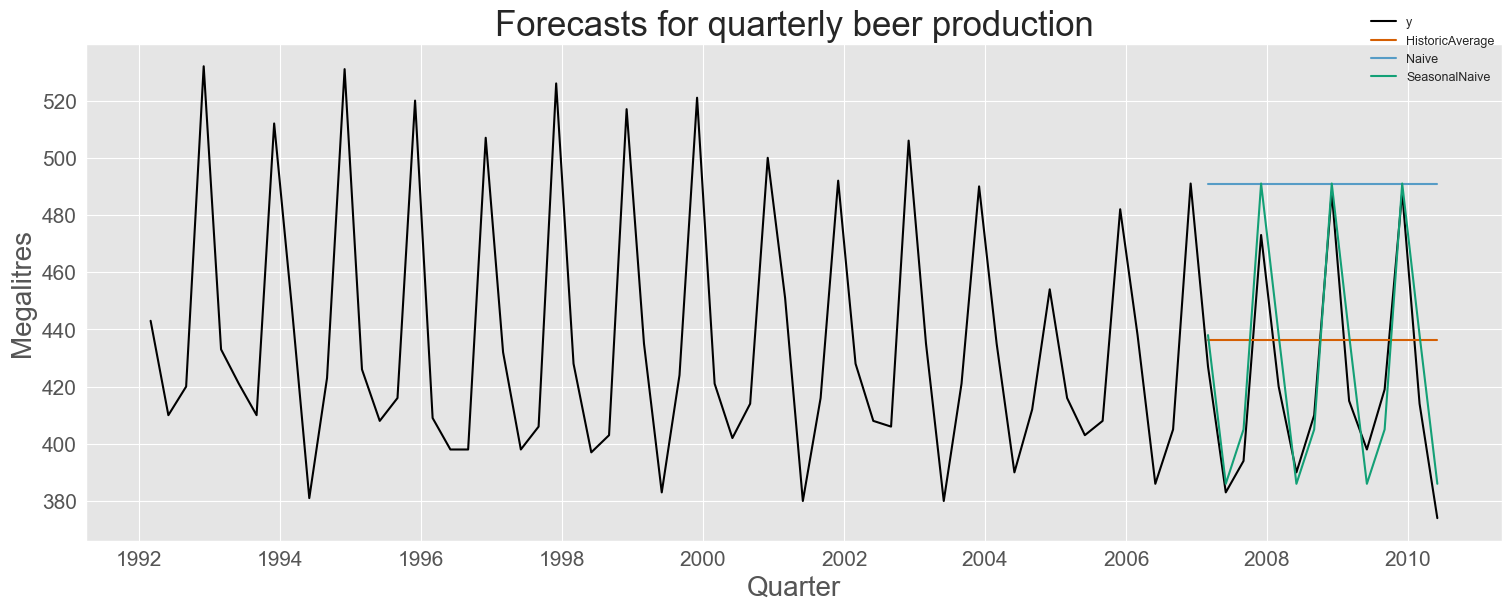

In [19]:
beers_df = production_df.loc[
    lambda x: (x["unique_id"] == "Beer") & (x["ds"] >= "1992")
]
train = beers_df.loc[lambda x: x["ds"] < "2007"]
test = beers_df.loc[lambda x: x["ds"] >= "2007"]

avg_method = HistoricAverage()
naive_method = Naive()
seasonal_naive_method = SeasonalNaive(4)

sf = StatsForecast(
    models=[avg_method, naive_method, seasonal_naive_method],
    freq=pd.offsets.QuarterBegin(1),
)
sf.fit(train)

fcasts = sf.predict(h=14).assign(y=test["y"].to_numpy())

plot_series(train, fcasts,
    xlabel="Quarter", ylabel="Megalitres",
    title="Forecasts for quarterly beer production",
    palette="black_and_3color", rm_legend=False)

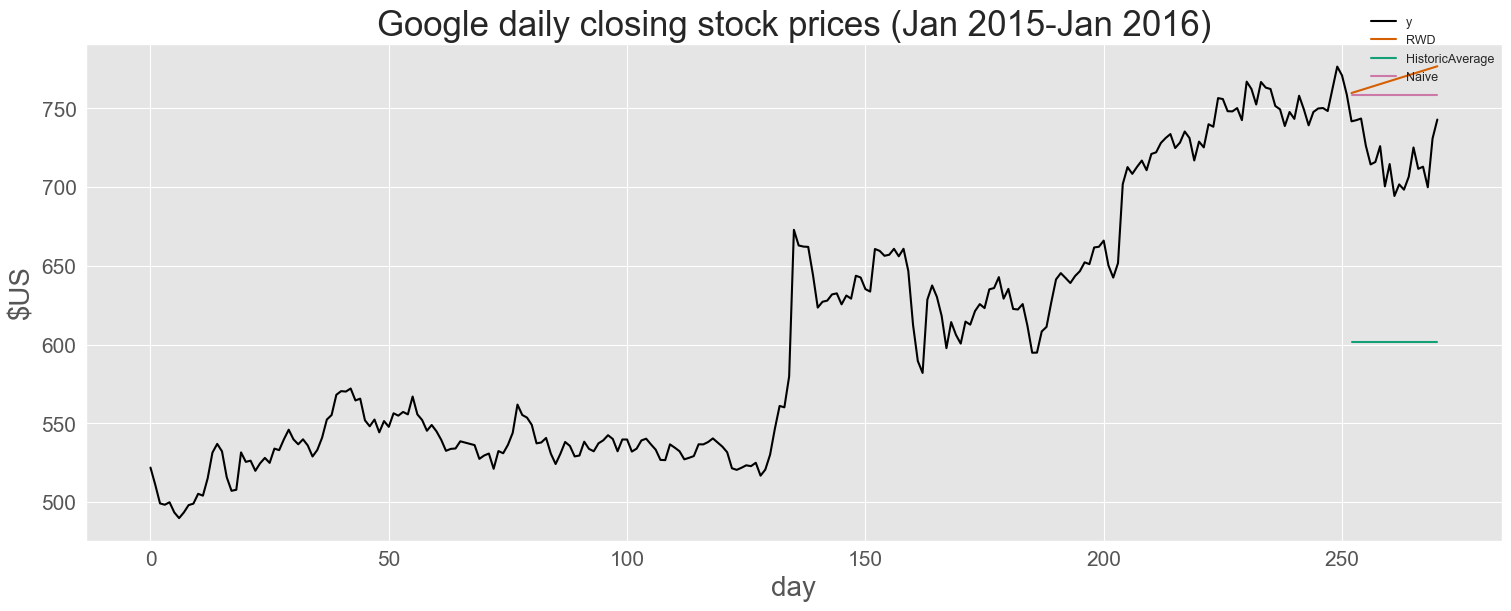

In [21]:
goog_df = (
    pd.read_csv("gafa_stock.csv", parse_dates=["ds"])
    .loc[lambda x: (
        (x["unique_id"] == "GOOG_Close")
        & x["ds"].between("2015", "2016-01-31")
    )]
)
train = goog_df.loc[lambda x: x["ds"].dt.year == 2015].copy()
test = goog_df.loc[lambda x: x["ds"].dt.year == 2016].copy()

# Re-index based on trading days
train["ds"] = np.arange(len(train))
test["ds"] = len(train) + np.arange(len(test))

avg_method = HistoricAverage()
naive_method = Naive()
drift_method = RandomWalkWithDrift()
sf = StatsForecast(freq=1,
    models=[drift_method, avg_method, naive_method])
sf.fit(train)

fcasts = sf.predict(h=len(test)).assign(y=test["y"].to_numpy())

plot_series(train, fcasts,
    xlabel="day", ylabel="$US",
    title="Google daily closing stock prices (Jan 2015-Jan 2016)",
    palette="black_and_4color", rm_legend=False)

In [22]:
train = beers_df.loc[lambda x: x["ds"] < "2007"]
test = beers_df.loc[lambda x: x["ds"] >= "2007"]

avg_method = HistoricAverage()
sf = StatsForecast(models=[avg_method], freq="Q")
sf.forecast(h=14, df=train, fitted=True)
fitted_values = sf.forecast_fitted_values()
df = train.assign(
    fitted=fitted_values["HistoricAverage"].to_numpy(),
    resid=lambda x: x["y"] - x["fitted"],
    innov=lambda x: x["y"] - x["fitted"],
)
df.head()

,unique_id,ds,y,fitted,resid,innov
144,Beer,1992-03-01,443.0,436.45,6.55,6.55
145,Beer,1992-06-01,410.0,436.45,-26.45,-26.45
146,Beer,1992-09-01,420.0,436.45,-16.45,-16.45
147,Beer,1992-12-01,532.0,436.45,95.55,95.55
148,Beer,1993-03-01,433.0,436.45,-3.45,-3.45


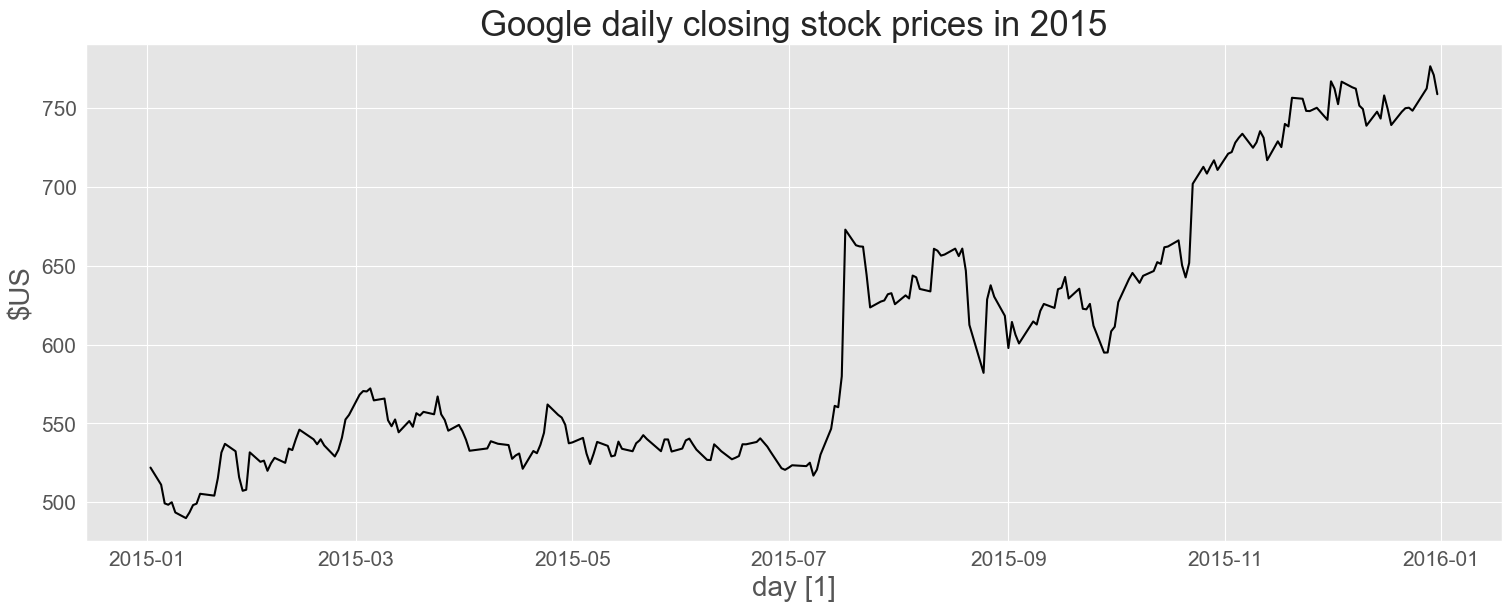

In [23]:
train = goog_df.loc[lambda x: x["ds"].dt.year == 2015]
plot_series(train,
    xlabel="day [1]", ylabel="$US",
    title="Google daily closing stock prices in 2015")

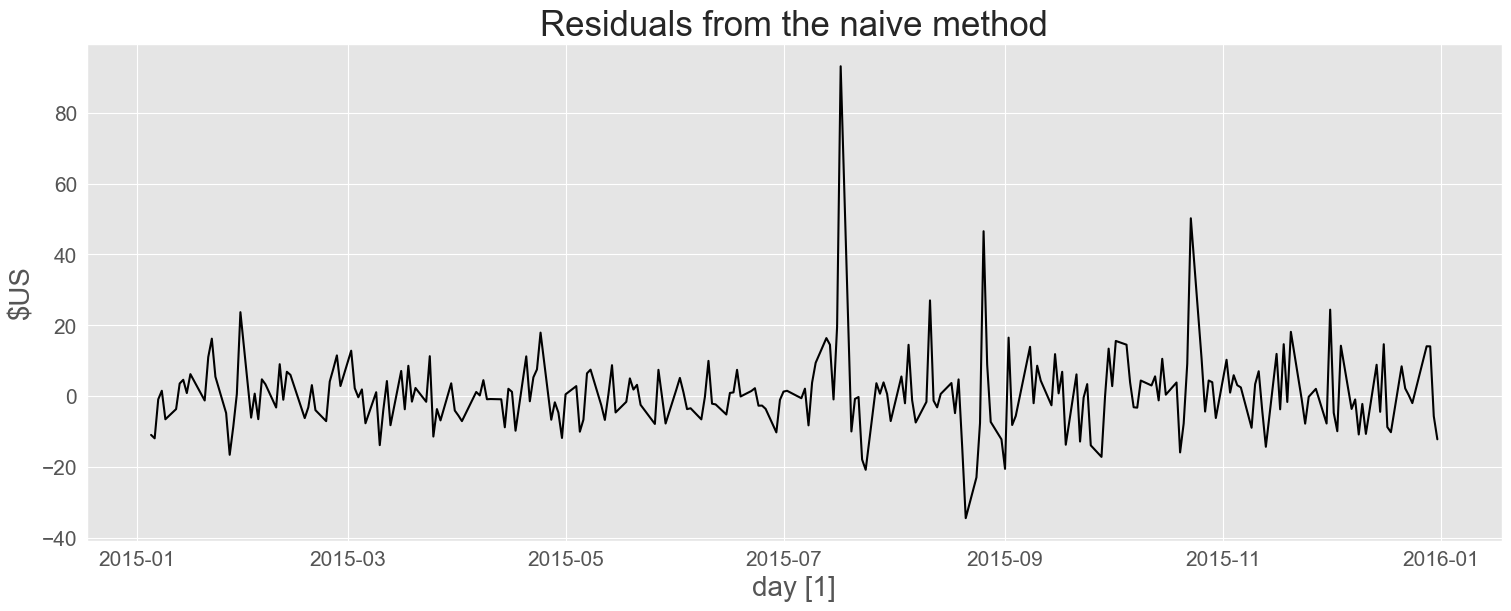

In [24]:
resid = train.assign(resid=lambda x: x["y"].diff())
plot_series(resid, target_col="resid",
    xlabel="day [1]", ylabel="$US",
    title="Residuals from the naive method")

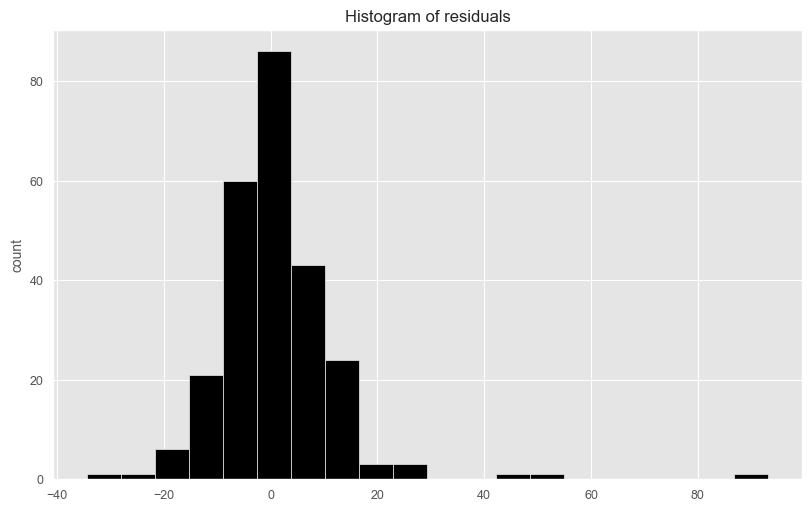

In [25]:
ax = resid["resid"].hist(bins=20)
ax.set(title="Histogram of residuals", ylabel="count")
plt.show()

[Text(0, 0.5, 'acf')]

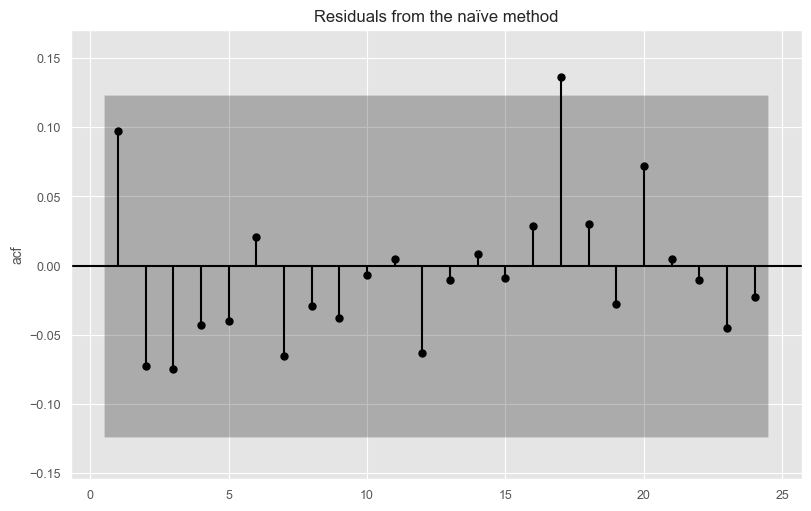

In [26]:
fig = plot_acf(resid["resid"][1:], zero=False, auto_ylims=True,
    bartlett_confint=False, title="Residuals from the naïve method")
fig.axes[0].set(ylabel="acf")

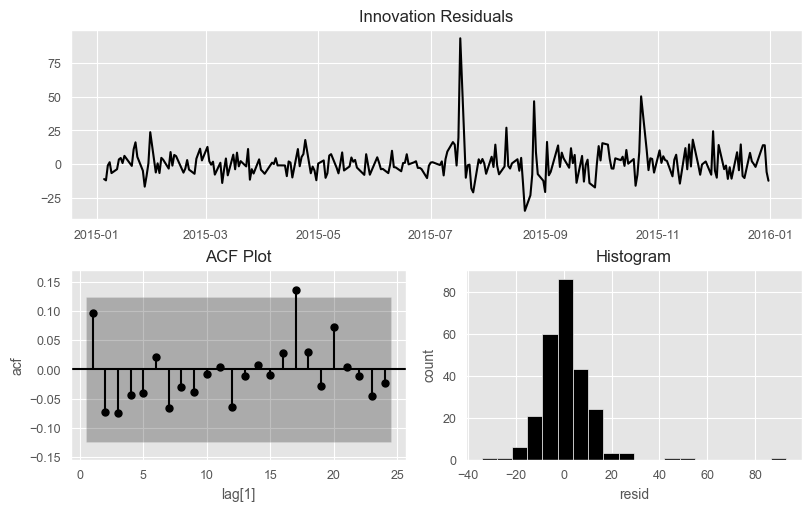

In [27]:
def plot_diagnostics(data):
    _, axes = plt.subplot_mosaic([["resid", "resid"], ["acf", "hist"]])

    ax = axes["resid"]
    ax.plot(data["ds"], data["resid"])
    ax.set(title="Innovation Residuals")

    ax = axes["acf"]
    plot_acf(data["resid"].dropna(),
        zero=False, bartlett_confint=False, auto_ylims=True, ax=ax)
    ax.set(title="ACF Plot", xlabel="lag[1]", ylabel="acf")

    ax = axes["hist"]
    ax.hist(data["resid"], bins=20)
    ax.set(title="Histogram", xlabel="resid", ylabel="count")

plot_diagnostics(resid)

In [28]:
resid_test = acorr_ljungbox(resid["resid"].dropna(), boxpierce=True)
resid_test

,lb_stat,lb_pvalue,bp_stat,bp_pvalue
1,2.417,0.120,2.389,0.122
2,3.761,0.153,3.711,0.156
3,5.193,0.158,5.115,0.164
4,5.675,0.225,5.585,0.232
5,6.084,0.298,5.983,0.308
6,6.195,0.402,6.090,0.413
7,7.303,0.398,7.159,0.413
8,7.525,0.481,7.372,0.497
9,7.902,0.544,7.733,0.561
10,7.914,0.637,7.745,0.654


In [29]:
drift_method = RandomWalkWithDrift()
sf = StatsForecast(models=[drift_method], freq="B")
sf.fit(train)
fcasts = sf.forecast(h=10, df=train, fitted=True)
insample = sf.forecast_fitted_values().assign(
    resid=lambda x: x["y"] - x["RWD"]
)
insample.head()

,unique_id,ds,y,RWD,resid
0,GOOG_Close,2015-01-02,521.938,NaN,NaN
1,GOOG_Close,2015-01-05,511.058,522.882,-11.824
2,GOOG_Close,2015-01-06,499.213,512.002,-12.789
3,GOOG_Close,2015-01-07,498.358,500.157,-1.799
4,GOOG_Close,2015-01-08,499.929,499.302,0.627


In [30]:
resid_test = acorr_ljungbox(insample["resid"].dropna(), boxpierce=True)
resid_test

,lb_stat,lb_pvalue,bp_stat,bp_pvalue
1,2.417,0.120,2.389,0.122
2,3.761,0.153,3.711,0.156
3,5.193,0.158,5.115,0.164
4,5.675,0.225,5.585,0.232
5,6.084,0.298,5.983,0.308
6,6.195,0.402,6.090,0.413
7,7.303,0.398,7.159,0.413
8,7.525,0.481,7.372,0.497
9,7.902,0.544,7.733,0.561
10,7.914,0.637,7.745,0.654


In [31]:
train = goog_df.loc[lambda x: x["ds"].dt.year == 2015].copy()
train["ds"] = np.arange(len(train))
naive_method = Naive()
sf = StatsForecast(models=[naive_method], freq=1)
fcasts = sf.forecast(df=train, h=10, level=[80, 95])
fcasts

,unique_id,ds,Naive,Naive-lo-80,Naive-lo-95,Naive-hi-80,Naive-hi-95
0,GOOG_Close,252,758.88,744.540,736.949,773.220,780.811
1,GOOG_Close,253,758.88,738.600,727.865,779.160,789.895
2,GOOG_Close,254,758.88,734.042,720.894,783.718,796.866
3,GOOG_Close,255,758.88,730.200,715.018,787.560,802.742
4,GOOG_Close,256,758.88,726.815,709.840,790.945,807.920
5,GOOG_Close,257,758.88,723.754,705.160,794.006,812.600
6,GOOG_Close,258,758.88,720.940,700.856,796.820,816.904
7,GOOG_Close,259,758.88,718.320,696.849,799.440,820.911
8,GOOG_Close,260,758.88,715.860,693.086,801.900,824.674
9,GOOG_Close,261,758.88,713.533,689.528,804.227,828.232


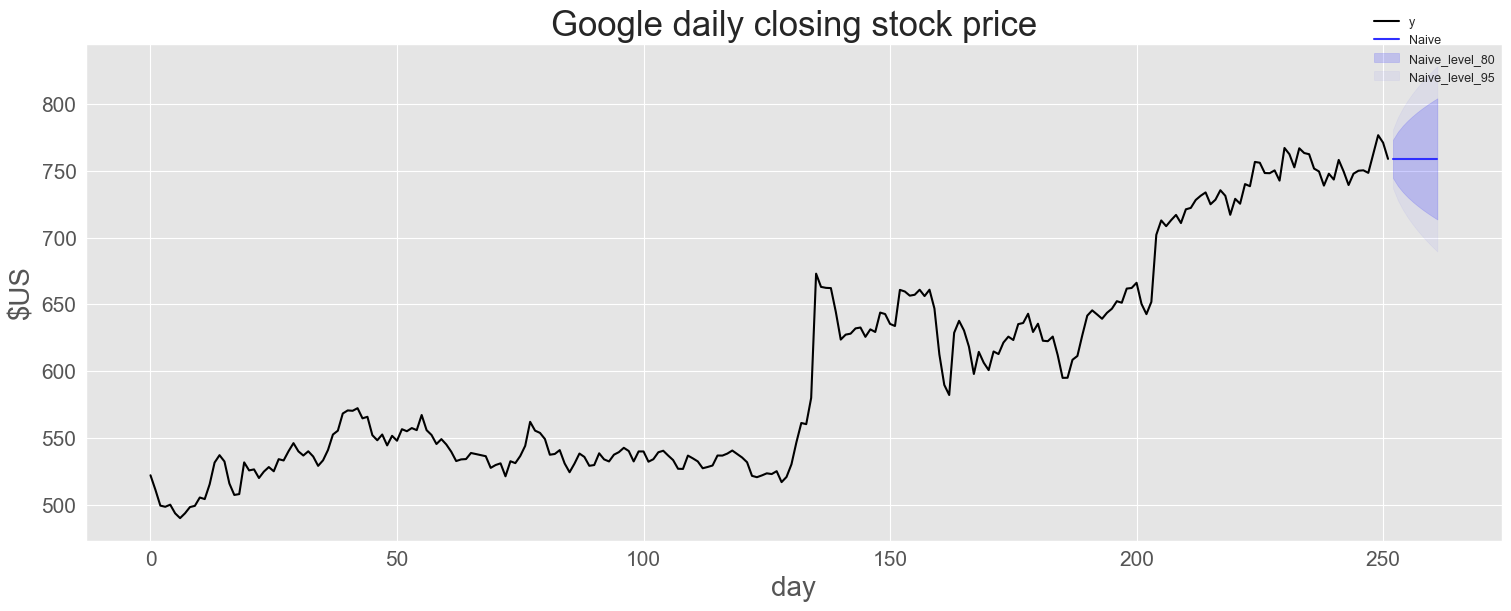

In [32]:
plot_series(train, fcasts, level=[80, 95],
    xlabel="day", ylabel="$US",
    title="Google daily closing stock price",
    palette="black_and_blue", rm_legend=False)

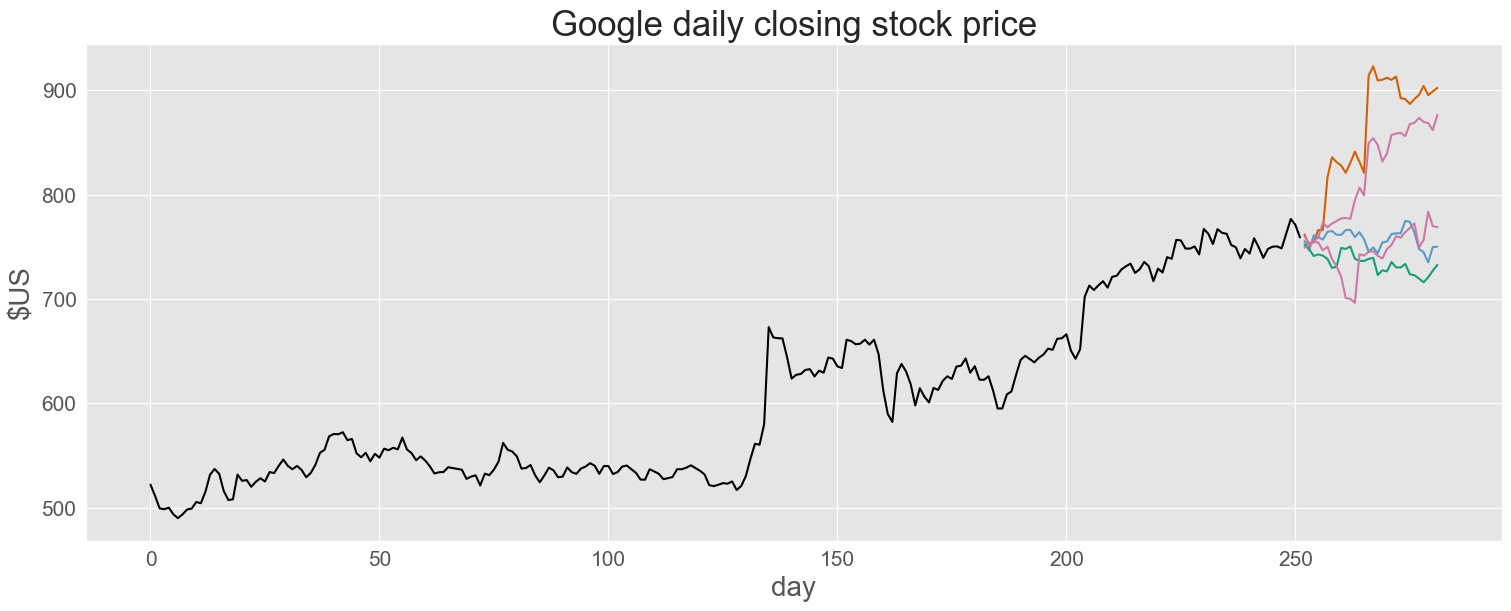

In [33]:
sf = StatsForecast(models = [Naive()], freq=1)
sf.forecast(h=30, df=train, fitted=True)
fitted = sf.forecast_fitted_values()
errors = (fitted["y"] - fitted["Naive"]).iloc[1:].to_list()
last_obs = train["y"].iloc[-1]

def generate_sim_df(num_sims, h):
    steps = np.random.choice(errors, size=(num_sims, h))
    sims = last_obs + steps.cumsum(axis=1)
    return pd.DataFrame({
        f"sim_{i}": sim
        for (i, sim) in enumerate(sims)
    })


sim_df = generate_sim_df(num_sims=5, h=30).assign(
    unique_id="GOOG_Close",
    ds=lambda x: train["ds"].max() + 1 + x.index,
)

plot_series(train, sim_df,
    models = ["sim_0", "sim_1", "sim_2", "sim_3", "sim_4"],
    xlabel="day", ylabel="$US",
    palette="black_and_4color", title="Google daily closing stock price",
)

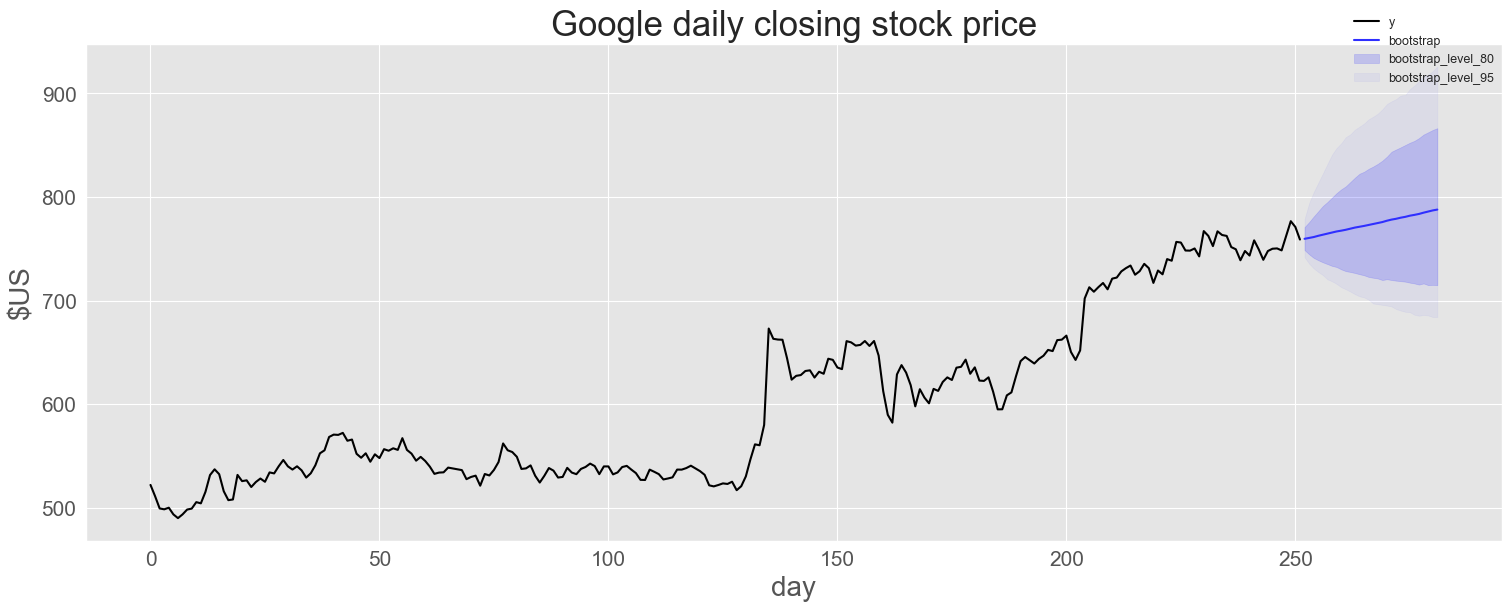

In [36]:
raw_df = generate_sim_df(num_sims=5000, h=30)
sim_df = raw_df.assign(**{
    "unique_id": "GOOG_Close",
    "ds": train["ds"].max() + 1 + raw_df.index,
    "bootstrap": raw_df.mean(axis="columns"),
    "bootstrap-lo-95": raw_df.quantile(0.025, axis="columns"),
    "bootstrap-lo-80": raw_df.quantile(0.1, axis="columns"),
    "bootstrap-hi-80": raw_df.quantile(0.9, axis="columns"),
    "bootstrap-hi-95": raw_df.quantile(0.975, axis="columns"),
})

plot_series(
    train, sim_df, models=["bootstrap"], level=[80, 95],
    xlabel="day", ylabel="$US", rm_legend=False,
    palette="black_and_blue", title="Google daily closing stock price")

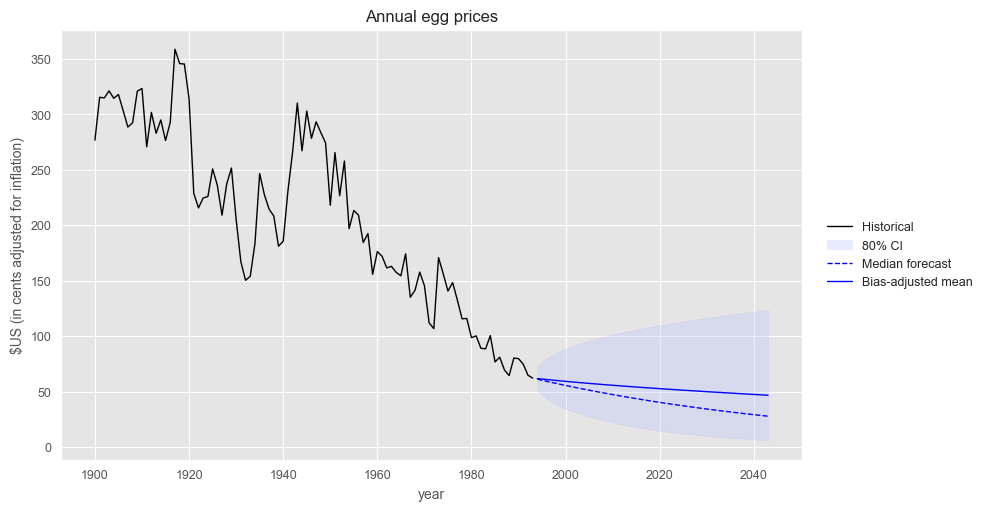

In [37]:
# Forecast on transformed series
egg_df = pd.read_csv("eggs.csv", parse_dates=["ds"])
egg_df_log = egg_df.assign(y=np.log(egg_df["y"]))
rwd_method = RandomWalkWithDrift()
sf = StatsForecast(models=[rwd_method], freq="Y")
sf.fit(egg_df_log)

# Find back-transformed values and apply bias correction
fcasts_log = sf.forecast(df=egg_df_log, h=50, level=[80, 95])
sigma_h = (fcasts_log["RWD-hi-80"] - fcasts_log["RWD-lo-80"]) / (2 * 1.28)
cols = ["RWD", "RWD-lo-80", "RWD-lo-95", "RWD-hi-80", "RWD-hi-95"]
fcasts = fcasts_log.assign(
    **{col: np.exp(fcasts_log[col]) for col in cols},
    **{"RWD-adjusted": np.exp(fcasts_log["RWD"]) * (1 + sigma_h**2 / 2)},
)

fig, ax = plt.subplots()
ax.plot(egg_df["ds"], egg_df["y"],
    color="black", label="Historical", linewidth=1)
ax.fill_between(fcasts["ds"], fcasts["RWD-lo-80"], fcasts["RWD-hi-80"],
    alpha=0.3, color="#B8BFFF", label="80% CI")
ax.plot(fcasts["ds"], fcasts["RWD"],
    color="blue", linestyle="--", label="Median forecast", linewidth=1)
ax.plot(fcasts["ds"], fcasts["RWD-adjusted"],
    color="blue", linestyle="-", label="Bias-adjusted mean", linewidth=1)
ax.set(
    title="Annual egg prices",
    xlabel="year",
    ylabel="$US (in cents adjusted for inflation)",
)
handles, labels = fig.axes[0].get_legend_handles_labels()
fig.legend(
    handles, labels, loc="center left", bbox_to_anchor=(1.02, 0.5),
    frameon=False, borderaxespad=0.0)
plt.show()

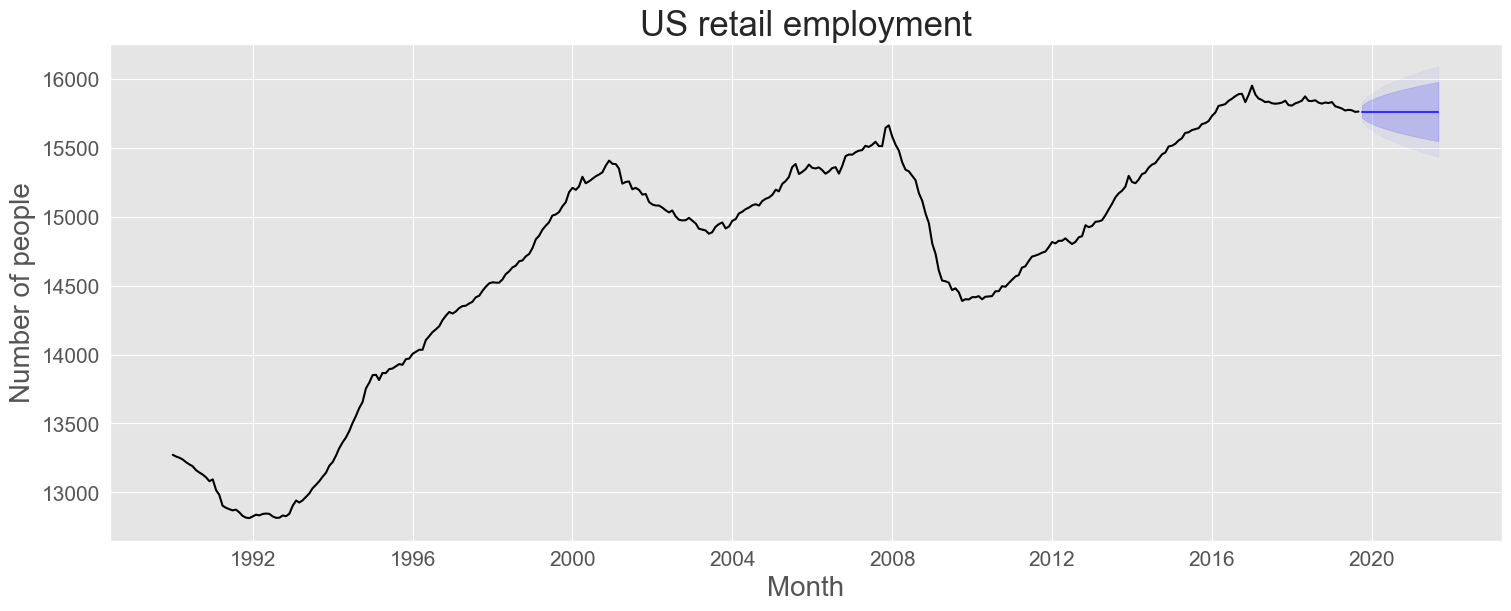

In [40]:
us_retail_employment_df = (
    pd.read_csv("us_employment.csv", parse_dates=["ds"])
    .loc[lambda x:
        (x["unique_id"] == "Retail Trade") & (x["ds"] >= "1990")
    ]
)

stl = STL(us_retail_employment_df["y"].to_numpy(), period=12, robust=True)
res = stl.fit()
train_df = us_retail_employment_df.assign(
    seasonal=res.seasonal,
    y_adjusted=lambda x: x["y"] - x["seasonal"],
)

naive_method = Naive()
sf = StatsForecast(models=[naive_method], freq="M")
adjusted_fcasts = sf.forecast(h=24, level=[80, 95],
    df=train_df, target_col="y_adjusted", fitted=True)
adjusted_fcasts_fitted = sf.forecast_fitted_values()

plot_series(train_df, adjusted_fcasts, target_col="y_adjusted",
    level=[80, 95], xlabel="Month", ylabel="Number of people",
    title="US retail employment", palette="black_and_blue")

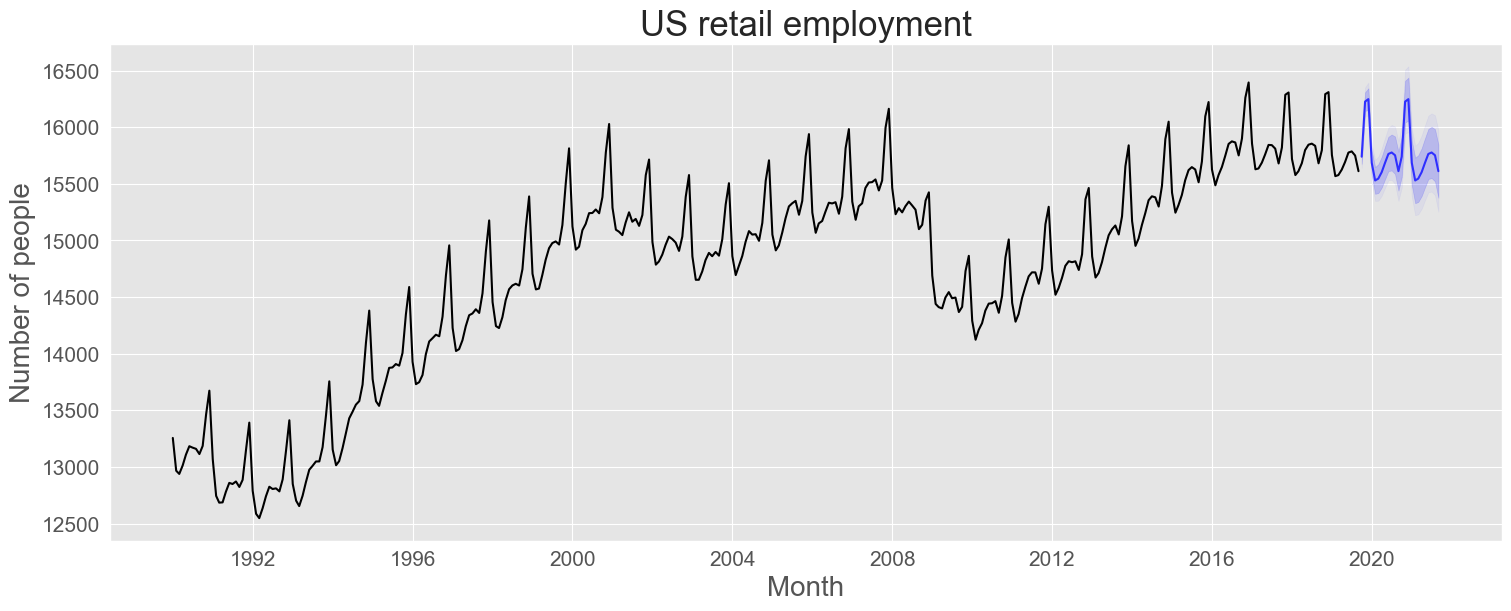

In [41]:
seasonal_naive = SeasonalNaive(12, alias="Seasonal")
sf = StatsForecast(models=[seasonal_naive], freq="M")
seasonal_fcasts = sf.forecast(h=24, level=[80, 95], df=train_df,
    target_col="seasonal", fitted=True)

raw_fcasts = adjusted_fcasts.merge(seasonal_fcasts, on=["unique_id", "ds"])
fcasts = raw_fcasts.assign(**{
    "combined": lambda x: x["Naive"] + x["Seasonal"],
    "combined-lo-95": lambda x: x["Naive-lo-95"] + x["Seasonal-lo-95"],
    "combined-lo-80": lambda x: x["Naive-lo-80"] + x["Seasonal-lo-80"],
    "combined-hi-80": lambda x: x["Naive-hi-80"] + x["Seasonal-hi-80"],
    "combined-hi-95": lambda x: x["Naive-hi-95"] + x["Seasonal-hi-95"],
})

seasonal_fcasts_fitted = sf.forecast_fitted_values()
fitted = (
    adjusted_fcasts_fitted
    .merge(seasonal_fcasts_fitted, on=["unique_id", "ds"])
    .assign(combined=lambda x: x["Naive"] + x["Seasonal"])
    .merge(train_df, on=["unique_id", "ds"], how="right")
    .assign(resid=lambda x: x["y"] - x["combined"])
)

plot_series(
    train_df, fcasts, level=[80, 95],
    target_col="y", models=["combined"],
    xlabel="Month", ylabel="Number of people",
    title="US retail employment", palette="black_and_blue")

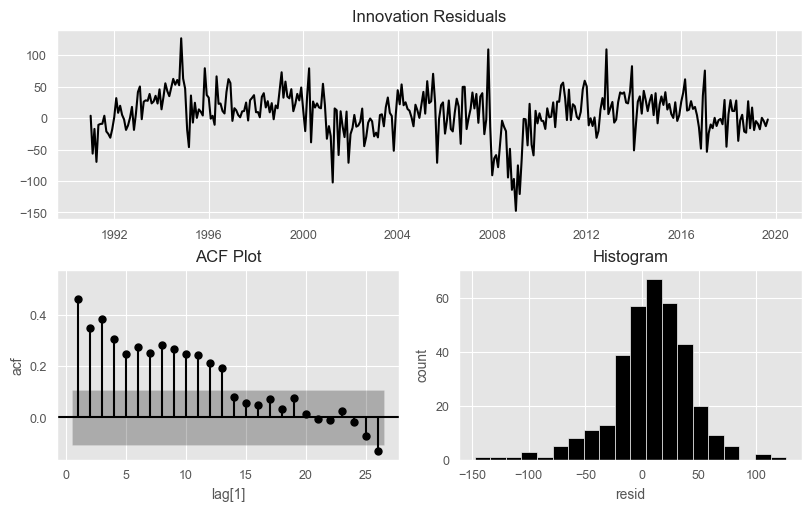

In [42]:
plot_diagnostics(fitted)

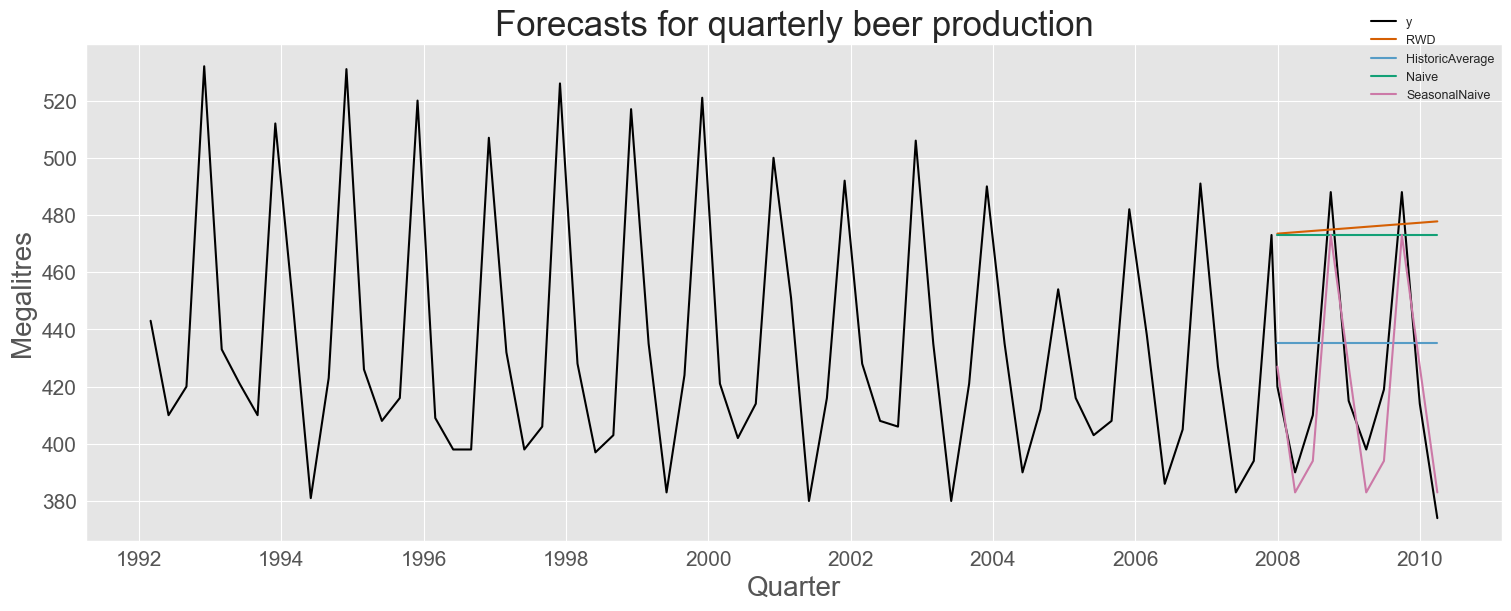

In [44]:
train_df = beers_df.loc[lambda x: x["ds"].dt.year <= 2007]
test_df = beers_df.loc[lambda x: x["ds"].dt.year > 2007]

mean_method = HistoricAverage()
naive_method = Naive()
drift_method = RandomWalkWithDrift()
seasonal_naive = SeasonalNaive(4)

sf = StatsForecast(freq="Q",
    models=[drift_method, mean_method, naive_method, seasonal_naive])
preds = (
    sf.forecast(df=train_df, h=10)
    .assign(y=test_df["y"].to_numpy())
)

plot_series(train_df, preds,
    xlabel="Quarter", ylabel="Megalitres",
    title="Forecasts for quarterly beer production",
    palette="black_and_4color", rm_legend=False)

In [47]:
evaluation = evaluate(preds, train_df=train_df,
    metrics=[rmse, mae, mape, partial(mase, seasonality=4)])

labels = {
    "method": "Method",
    "rmse": "RMSE", "mae": "MAE",
    "mape": "MAPE", "mase": "MASE",
}
evaluation_transformed = (
    evaluation
    .drop(columns=["unique_id"]).set_index("metric")
    .rename_axis("", axis="rows").rename_axis("Method", axis="columns")
    .transpose().reset_index().rename(columns=labels)
)
evaluation_transformed

,Method,RMSE,MAE,MAPE,MASE
0,RWD,64.901,58.876,14.577,4.117
1,HistoricAverage,38.447,34.825,8.283,2.435
2,Naive,62.693,57.400,14.184,4.014
3,SeasonalNaive,14.311,13.400,3.169,0.937


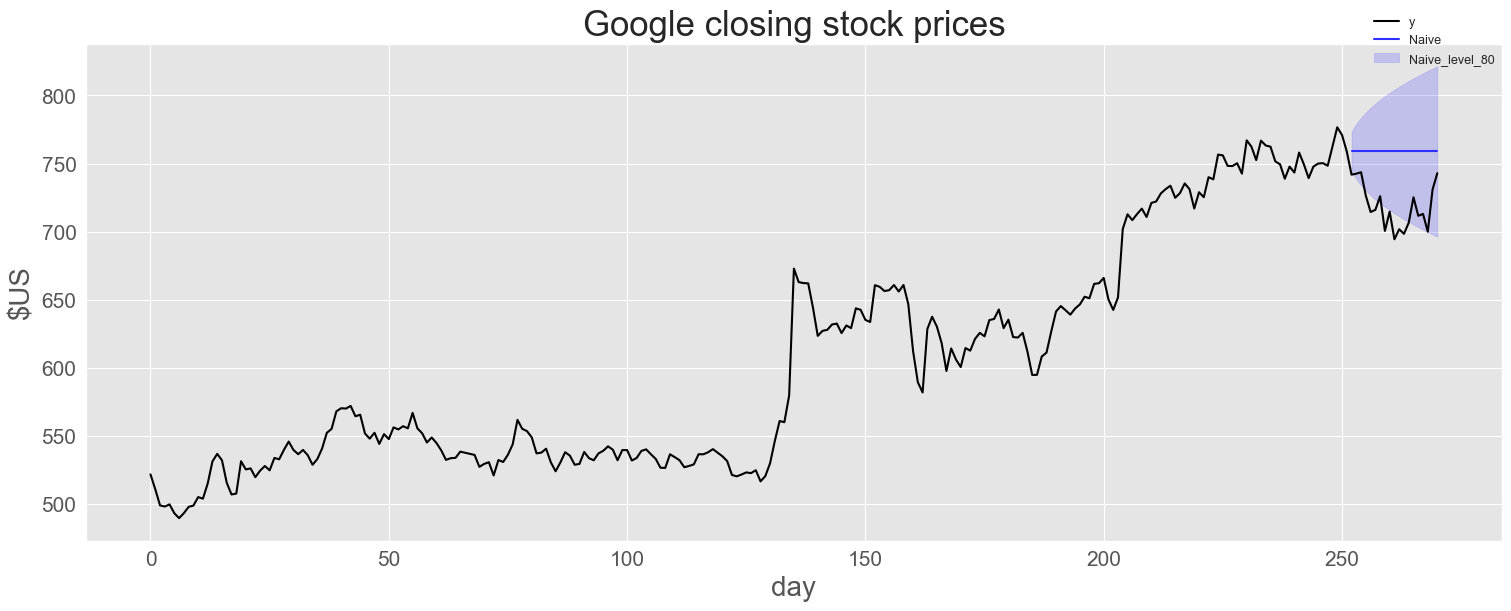

In [49]:
train_df = goog_df.loc[lambda x: x["ds"].dt.year == 2015].copy()
test_df = goog_df.loc[lambda x: x["ds"].dt.year == 2016].copy()
train_df["ds"] = np.arange(len(train_df["ds"]))
test_df["ds"] = len(train_df) + np.arange(len(test_df))

naive_model = Naive()

sf = StatsForecast(models=[naive_model], freq=1)
preds = (
    sf.forecast(h=19, level=[80], df=train_df)
    .assign(y=test_df["y"].to_numpy())
)

plot_series(train_df, preds, level=[80],
    xlabel="day", ylabel="$US",
    title="Google closing stock prices",
    palette="black_and_blue", rm_legend=False)

In [51]:
evaluation = evaluate(preds, metrics=[quantile_loss], level=[80])
labels = {
    "method": "Method",
    "quantile_loss_q0.1": "Quantile loss (q=0.1)",
    "quantile_loss_q0.9": "Quantile loss (q=0.9)",
}
evaluation_transformed = (
    evaluation
    .drop(columns=["unique_id"]).set_index("metric")
    .rename_axis("", axis="rows").rename_axis("Method", axis="columns")
    .transpose().reset_index().rename(columns=labels)
)
evaluation_transformed

,Method,Quantile loss (q=0.1),Quantile loss (q=0.9)
0,Naive,4.775,8.355


In [52]:
def winkler_score(preds, model, alpha=0.2):
    pct = int(100 * (1 - alpha))
    lo = preds[f"{model}-lo-{pct}"]
    hi = preds[f"{model}-hi-{pct}"]
    y = preds["y"]
    return hi - lo + np.select(
        [(lo <= y) & (y <= hi), (y < lo), (y > hi)],
        [0, (2 / alpha) * (lo - y), (2 / alpha) * (y - hi)],
    )

winkler_score_df = pd.DataFrame({
    "Method": "Naive",
    "Winkler score": winkler_score(preds, "Naive"),
})
winkler_score_df.head(1)

,Method,Winkler score
0,Naive,55.68


In [53]:
train_df = goog_df.loc[lambda x: x["ds"].dt.year == 2015].copy()
test_df = goog_df.loc[lambda x: x["ds"].dt.year == 2016].copy()
mean_method = HistoricAverage()
naive_method = Naive()
drift_method = RandomWalkWithDrift()
sf = StatsForecast(
    freq="B", models=[drift_method, naive_method, mean_method])

levels = list(np.arange(0, 100, 1 / 10))
preds = (
    sf.forecast(df=train_df, h=len(test_df), level=levels)
    .assign(y=test_df["y"].to_numpy())
)

models = ["RWD", "HistoricAverage", "Naive"]
raw_crps_df = evaluate(
    df=preds, models=models, metrics=[mqloss], level=levels)
crps_series = 2 * raw_crps_df[models].iloc[0].rename_axis("Method")
crps_df = crps_series.rename("CRPS").reset_index()
crps_df

,Method,CRPS
0,RWD,33.557
1,HistoricAverage,76.789
2,Naive,26.500


In [54]:
naive_crps = crps_series.loc["Naive"]
crps_skill_df = crps_df.assign(
    skill_score=(naive_crps - crps_df["CRPS"]) / naive_crps)
crps_skill_df

,Method,CRPS,skill_score
0,RWD,33.557,-0.266
1,HistoricAverage,76.789,-1.898
2,Naive,26.500,0.000


In [55]:
goog_2015 = goog_df.loc[lambda x: x["ds"].dt.year == 2015].copy()

drift_method = RandomWalkWithDrift()
sf = StatsForecast(models=[drift_method], freq="B")
cv_df = sf.cross_validation(h=1, df=goog_2015, step_size=1, test_size=249)
cv_df.head()

,unique_id,ds,cutoff,y,RWD
0,GOOG_Close,2015-01-07,2015-01-06,498.358,487.850
1,GOOG_Close,2015-01-08,2015-01-07,499.929,490.497
2,GOOG_Close,2015-01-09,2015-01-08,493.454,494.427
3,GOOG_Close,2015-01-12,2015-01-09,489.854,487.758
4,GOOG_Close,2015-01-13,2015-01-12,493.464,484.507


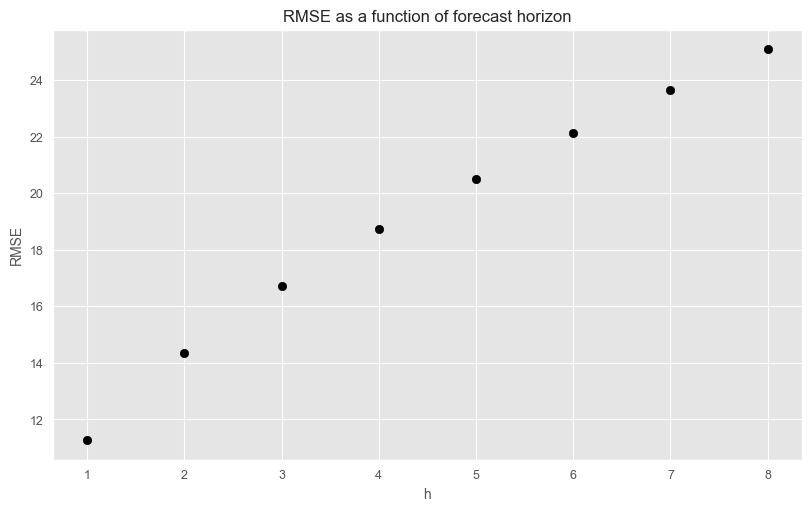

In [56]:
rmses = []
horizons = np.arange(1, 9)
for horizon in horizons:
    drift_model = RandomWalkWithDrift()
    sf = StatsForecast(models=[drift_model], freq="B")
    cv_df = sf.cross_validation(
        h=horizon, df=goog_2015, step_size=1, test_size=249)
    cv_evaluation = evaluate(cv_df, metrics=[rmse], models=["RWD"])
    rmses.append(cv_evaluation["RWD"].iloc[0])

fig, ax = plt.subplots()
ax.scatter(horizons, rmses)
ax.set(
    title="RMSE as a function of forecast horizon",
    xlabel="h",
    ylabel="RMSE",
)
plt.show()